## Across trial variability DDM: parameter recovery

DDM with drift rate, starting point, boundary, and non-decision time. 

The drift rate on trial $t$, $v_t$, is drawn from a normal distribution, centered around the overall drift rate $v$, with standard deviation $s_v$: 

$v_t$ ~ N($v$, $s_v$)

The starting point on each trial, $z_t$, comes from a uniform distribution, centered around the overall starting point $z$, with range $s_z$:

$z_t$ ~ U($z$-$s_z$/2, $z$+$s_z$/2, [0,1])

Drift rate is multiplied with stimulus (uniform between -1 or +1).

In [1]:
import numpy as np
import os
from numba import njit
import bayesflow as bf
import tensorflow as tf
from scipy.stats import uniform, pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd

from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32

import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)
from tensorflow.python.platform import build_info as tf_build_info
print("cudnn_version",tf_build_info.build_info['cudnn_version'])
print("cuda_version",tf_build_info.build_info['cuda_version'])

2026-06-30 10:22:55.425419: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-30 10:22:55.425457: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-30 10:22:55.426733: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-30 10:22:55.433361: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-06-30 10:22:56.866233: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


cudnn_version 8
cuda_version 12.2


In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Create folder if it does not exist
os.makedirs("Figures", exist_ok=True)
os.makedirs("Data", exist_ok=True)

## Set priors

In [4]:
RNG = np.random.default_rng(0)

min_n_trials = 500
max_n_trials = 500

batch_size = 32

"""
Set parameters for prior distributions
"""

v_lower, v_upper = 0.0, 5.0
z_lower, z_upper = -2.0, 2.0 # sigmoid transformation is used to keep z+z_bias between 0 and 1
a_lower, a_upper = 0.1, 5.0
ter_lower, ter_upper = 0.01, 1.0

sv_lower, sv_upper = 0.0, 2.5
sz_lower, sz_upper = 0.0, 2.5 # also before sigmoid transformation

## Prior functions

In [5]:
def sample_shared_parameters():
    """
    Drift rate, starting point, boundary, non-decision time
    """
    
    v = np.random.uniform(v_lower, v_upper) # drift rate
    z = np.random.uniform(z_lower, z_upper) # starting point (relative to boundary), before sigmoid transformation
    a = np.random.uniform(a_lower, a_upper) # boundary
    ter = np.random.uniform(ter_lower, ter_upper) # non-decision time
    
    sv = np.random.uniform(sv_lower, sv_upper) # boundary
    sz = np.random.uniform(sz_lower, sz_upper) # non-decision time
    
    shared_parameters = np.concatenate([np.r_[v, z, a, ter, sv, sz]])
    
    return shared_parameters

## Sample diffusion trial

In [6]:
@cuda.jit
def _sample_one_diffusion_trial(rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_sv, in_sz, num_threads):
    """
    Simulate one-trial diffusion process with across-trial variability
    in drift rate (sv) and starting point (sz).
    """
    
    thread_id = cuda.grid(1)
    
    if (thread_id < num_threads):
        
        # Input parameters
        v = in_v[thread_id]
        z = in_z[thread_id]
        a = in_a[thread_id]
        ter = in_ter[thread_id]
        sv = in_sv[thread_id]
        sz = in_sz[thread_id]
        
        # Simulation parameters
        dt=0.005             # time resolution of process, 5 milliseconds
        max_iter=int(5/dt)   # max iterations of the process, 5 seconds (1000 iterations)
        s=1.0                # scaling factor of the Wiener noise
        c = (dt * s)**0.5    # np.sqrt does not work with cuda.jit    

        # Across-trial variability
        z_t = z + sz * (xoroshiro128p_uniform_float32(rng_states, thread_id) - 0.5) # trick to sample from U(z-sz/2, z+sz/2) within numba
        v_t = v + sv * xoroshiro128p_normal_float32(rng_states, thread_id)

        # Initialize
        transformed_z = 1/(1+math.exp(-z_t)) # constrain z_t between 0 and 1 with sigmoid transformation
        evidence = a * (transformed_z)       # initialize first value (starting point plus bias relative to boundary)
        slope_dt = v_t*dt
        n_iter = 0
        
        # Diffusion process
        while evidence > 0 and evidence < a and n_iter < max_iter:
            n_iter += 1
            evidence += slope_dt + c * xoroshiro128p_normal_float32(rng_states, thread_id)
        
        # Determine response
        rt = n_iter * dt + ter
        
        if evidence >= a:
            resp =  1
        elif evidence <= 0:
            resp = 0
            
        out_rt[thread_id] = rt
        out_resp[thread_id] = resp

## Cuda helper functions

In [7]:
@njit(fastmath=True)
def cuda_convert_parameters(shared_parameters, condition_matrix, num_trials):
    """
    Convert the batched parameters into a vector for each parameter separately (needed for GPU threads)
    """
    
    batch_size = shared_parameters.shape[0]

    in_v = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_z = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_a = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_ter = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_sv = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_sz = np.zeros(batch_size * num_trials, dtype=np.float32)

    for dataset in range(batch_size): # loop over datasets
    
        shared_parameters_subset = shared_parameters[dataset]
        condition_matrix_subset = condition_matrix[dataset]
        
        for trial in range(num_trials): # loop over trials
                
            in_index = dataset * num_trials + trial

            in_v[in_index] = shared_parameters_subset[0] * condition_matrix_subset[trial] # multiply drift rate with stimulus
            in_z[in_index] = shared_parameters_subset[1]
            in_a[in_index] = shared_parameters_subset[2]
            in_ter[in_index] = shared_parameters_subset[3]
            in_sv[in_index] = shared_parameters_subset[4]
            in_sz[in_index] = shared_parameters_subset[5]

    return in_v, in_z, in_a, in_ter, in_sv, in_sz


@njit(fastmath=True)
def cuda_convert_sim_data(shared_parameters, condition_matrix, num_trials, out_rt, out_resp):
    """
    Convert GPU thread output back to Bayesflow format
    """
    
    batch_size = shared_parameters.shape[0]

    out = np.zeros((batch_size, num_trials, 2), dtype=np.float32) # rt, resp

    for dataset in range(batch_size): # loop over datasets
        for trial in range(num_trials): # loop over trials

            # simulated data as a 3D tensor of shape (num_datasets, num_trials, num_variables)
            out_index = dataset * num_trials + trial
            out[dataset, trial, :] = np.array([out_rt[out_index], out_resp[out_index]], dtype=np.float32)

    return out

## Sample multiple diffusion trials

In [8]:
# in addition to the vector of parameters, our simulator takes the design matrix (i.e., batchable context) 
# and the number of observations (i.e., non-batchable context) as arguments
def sample_multiple_diffusion_trials(shared_parameters, condition_matrix, num_trials):
    """
    Generates DDM data for one participants with N trials
    """

    batch_size = shared_parameters.shape[0]
    
    threads_per_block = 32
    total_threads = int(batch_size * num_trials)
    blocks = math.ceil(total_threads / threads_per_block)
    rng_states = create_xoroshiro128p_states(total_threads, seed=0)
    
    in_v, in_z, in_a, in_ter, in_sv, in_sz = cuda_convert_parameters(shared_parameters, condition_matrix, num_trials)    
    
    # one iteration happens fully in parallel (so each trial for all datasets in parallel)
    out_rt = np.zeros(batch_size * num_trials, dtype=np.float32)
    out_resp = np.zeros(batch_size * num_trials, dtype=np.float32)
    
    # KEY LINE: each GPU thread will compute one DDM trial!
    _sample_one_diffusion_trial[blocks, threads_per_block](rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_sv, in_sz, total_threads)

    out = cuda_convert_sim_data(shared_parameters, condition_matrix, num_trials, out_rt, out_resp)
    
    return out

## Helper functions

In [9]:
def return_mean_std_shared_parameters():
    """
    Return the mean and standard deviation of shared parameters
    """
    
    v_mean, v_std = uniform.stats(v_lower, v_upper, moments='mv')
    z_mean, z_std = uniform.stats(z_lower, z_upper, moments='mv')
    a_mean, a_std = uniform.stats(a_lower, a_upper, moments='mv')
    ter_mean, ter_std = uniform.stats(ter_lower, ter_upper, moments='mv')
    sv_mean, sv_std = uniform.stats(sv_lower, sv_upper, moments='mv')
    sz_mean, sz_std = uniform.stats(sz_lower, sz_upper, moments='mv')
    
    mean_shared = np.array([v_mean, z_mean, a_mean, ter_mean, sv_mean, sz_mean])
    std_shared = np.array([v_std, z_std, a_std, ter_std, sv_std, sz_std])
    
    return mean_shared, std_shared


In [10]:
def sample_n_trials(min_n_trials=min_n_trials, max_n_trials=max_n_trials):
    """
    Samples the number of trials used for all simulations in one batch.
    """
    
    num_trials = np.random.randint(min_n_trials, max_n_trials+1)
    
    return num_trials


def generate_condition_matrix(num_trials):
    """
    Draws a random design matrix (stimulus: either -1 or +1 on each trial) for each simulation in a batch.
    """
    
    condition_matrix = np.random.uniform(-1, 1, size=num_trials)

    return condition_matrix


## Setting up generator

In [11]:
prior = bf.simulation.Prior(prior_fun=sample_shared_parameters) 

experimental_context = bf.simulation.ContextGenerator(non_batchable_context_fun=sample_n_trials,
                                                      batchable_context_fun=generate_condition_matrix,
                                                      use_non_batchable_for_batchable=True)

simulator = bf.simulation.Simulator(batch_simulator_fun=sample_multiple_diffusion_trials,
                                    context_generator=experimental_context)

generative_model = bf.simulation.GenerativeModel(prior=prior, 
                                                 simulator=simulator) 

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 32 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/cuda/core/experimental/_linker.py:189: RuntimeWarning: nvJitLink is not installed or too old (<12.3). Therefore it is not usable and the culink APIs will be used instead.
  _lazy_init()
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


INFO:root:Performing 2 pilot runs with the anonymous model...


INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 6)


INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 500, 2)


INFO:root:No optional prior non-batchable context provided.


INFO:root:No optional prior batchable context provided.


INFO:root:Could not determine shape of simulation non-batchable context. Type appears to be non-array: <class 'int'>,                                    so make sure your input configurator takes cares of that!


INFO:root:Could not determine shape of simulation batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes cares of that!


## Setting up amortizer

In [12]:
""" 
summary_net: 
    learns the most informative summary stats from data 
inference_net: 
    from summary statistics to posterior distributions - joint posterior distribution
amortizer: 
    connects the two networks
"""


summary_net = bf.networks.SetTransformer(input_dim=3, summary_dim=32) # input_dim: rt, response, stimulus
inference_net = bf.networks.InvertibleNetwork(num_params=6) # v,z,a,ter,sv,sz
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

2026-06-30 10:23:06.215790: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15507 MB memory:  -> device: 0, name: Tesla P100-SXM2-16GB, pci bus id: 0000:62:00.0, compute capability: 6.0


## Checkpoint path

In [13]:
checkpoint_path = f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/2. Across-trial variability DDM/training_across_trial_variability_ddm"
if not os.path.exists(checkpoint_path):
    os.makedirs(checkpoint_path)

## Create configurator

In [14]:

"""
takes the raw outputs of the generative models and turns them into something with which neural networks can work
"""


def configurator(raw_dict, transform=True):
        """Configures the output of self.generator for a BayesFlow pipeline.

        1. Converts float64 to float32 (for TensorFlow)
        2. Scale the model parameters if tranform=True

        Parameters:
        -----------
        raw_dict  : dict
            A simulation dictionary as returned by ``bayesflow.simulation.GenerativeModel``
        transform : boolean, optional, default: True
            An indicator to standardize the parameter and log-transform reaction times. 

        Returns:
        --------
        input_dict : dict
            The simulation dictionary configured for ``bayesflow.amortizers.Amortizer``
        """

        # Convert to float32
        shared_parameters = raw_dict.get("prior_draws").astype(np.float32)

        # Convert list of condition indicators to a 2D array and add a
        # trailing dimension of 1, so shape becomes (batch_size, num_obs, 1)
        # We need this in order to easily concatenate the context (condition matrix) with the data
        context = np.array(raw_dict["sim_batchable_context"])[..., None]
        data = raw_dict.get("sim_data").astype(np.float32) # [batch_size, num_trials, 2], last dimension is (rt, resp)

        # Concatenate data (rt, resp) and context (condition matrix)
        summary_conditions = np.c_[data, context].astype(np.float32)

        # Make inference network aware of varying numbers of trials
        # We create a vector of shape (batch_size, 1) by repeating the sqrt(num_trials)
        # num_trials calculated as the length of the condition matrix
        vec_num_trials = context.shape[1] * np.ones((data.shape[0], 1))
        direct_conditions = np.sqrt(vec_num_trials).astype(np.float32)

        if transform:
            mean_shared, std_shared = return_mean_std_shared_parameters()
            
            # Log transform reaction times
            summary_conditions[:,:,0] = np.log(summary_conditions[:,:,0])
            
            out_dict = dict(
                parameters=(shared_parameters-mean_shared.astype(np.float32))/std_shared.astype(np.float32),
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions # see https://bayesflow.org/_examples/LCA_Model_Posterior_Estimation.html#defining-the-configurator
            )
            
        else:
            out_dict = dict(
                parameters=shared_parameters,
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions
            )

        return out_dict


In [15]:
raw_sample = generative_model(batch_size=1)
configured_output = configurator(raw_sample)

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


## Loading in trained model

In [16]:
"""
Connect the networks (summary and inference) with the generative model 
"""


trainer = bf.trainers.Trainer(
    amortizer=amortizer,
    generative_model=generative_model,
    configurator=configurator,
    checkpoint_path=checkpoint_path)


INFO:root:Loaded loss history from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/2. Across-trial variability DDM/training_across_trial_variability_ddm/history_500.pkl.


INFO:root:Networks loaded from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/2. Across-trial variability DDM/training_across_trial_variability_ddm/ckpt-500


INFO:root:Performing a consistency check with provided components...


INFO:root:Done.


## Parameter recovery

In [17]:
# if num_trials here differs from those used for training the model:
# change arguments sample_num_trials such that only one value is drawn (the num_trials here below)
# then rerun all code uptil the actual training

num_trials = 500
num_simulations = 1000
num_posterior_samples = 50
num_shared_parameters = 6


estimated_shared = np.zeros((num_simulations, num_posterior_samples, num_shared_parameters))
true_shared = np.zeros((num_simulations, num_shared_parameters))

mean_shared, std_shared = return_mean_std_shared_parameters()


for sim in range(num_simulations):
    #print(sim)
    # Samples true values and rt's and save them
    true_param_values_and_rt = trainer.configurator(generative_model(1))
    true_shared[sim] = true_param_values_and_rt["parameters"][0] * std_shared + mean_shared

    # Sample posterior (estimated) values and save them
    posterior_samples = amortizer.sample(true_param_values_and_rt, n_samples=num_posterior_samples) # n_samples from posterior
    
    estimated_shared[sim] = posterior_samples * std_shared + mean_shared


# Calculate mean and std over posterior samples for each simulation
estimated_shared_mean = estimated_shared.mean(axis=1)
estimated_shared_std = estimated_shared.std(axis=1)

## 1. Correlation true and estimated posterior means

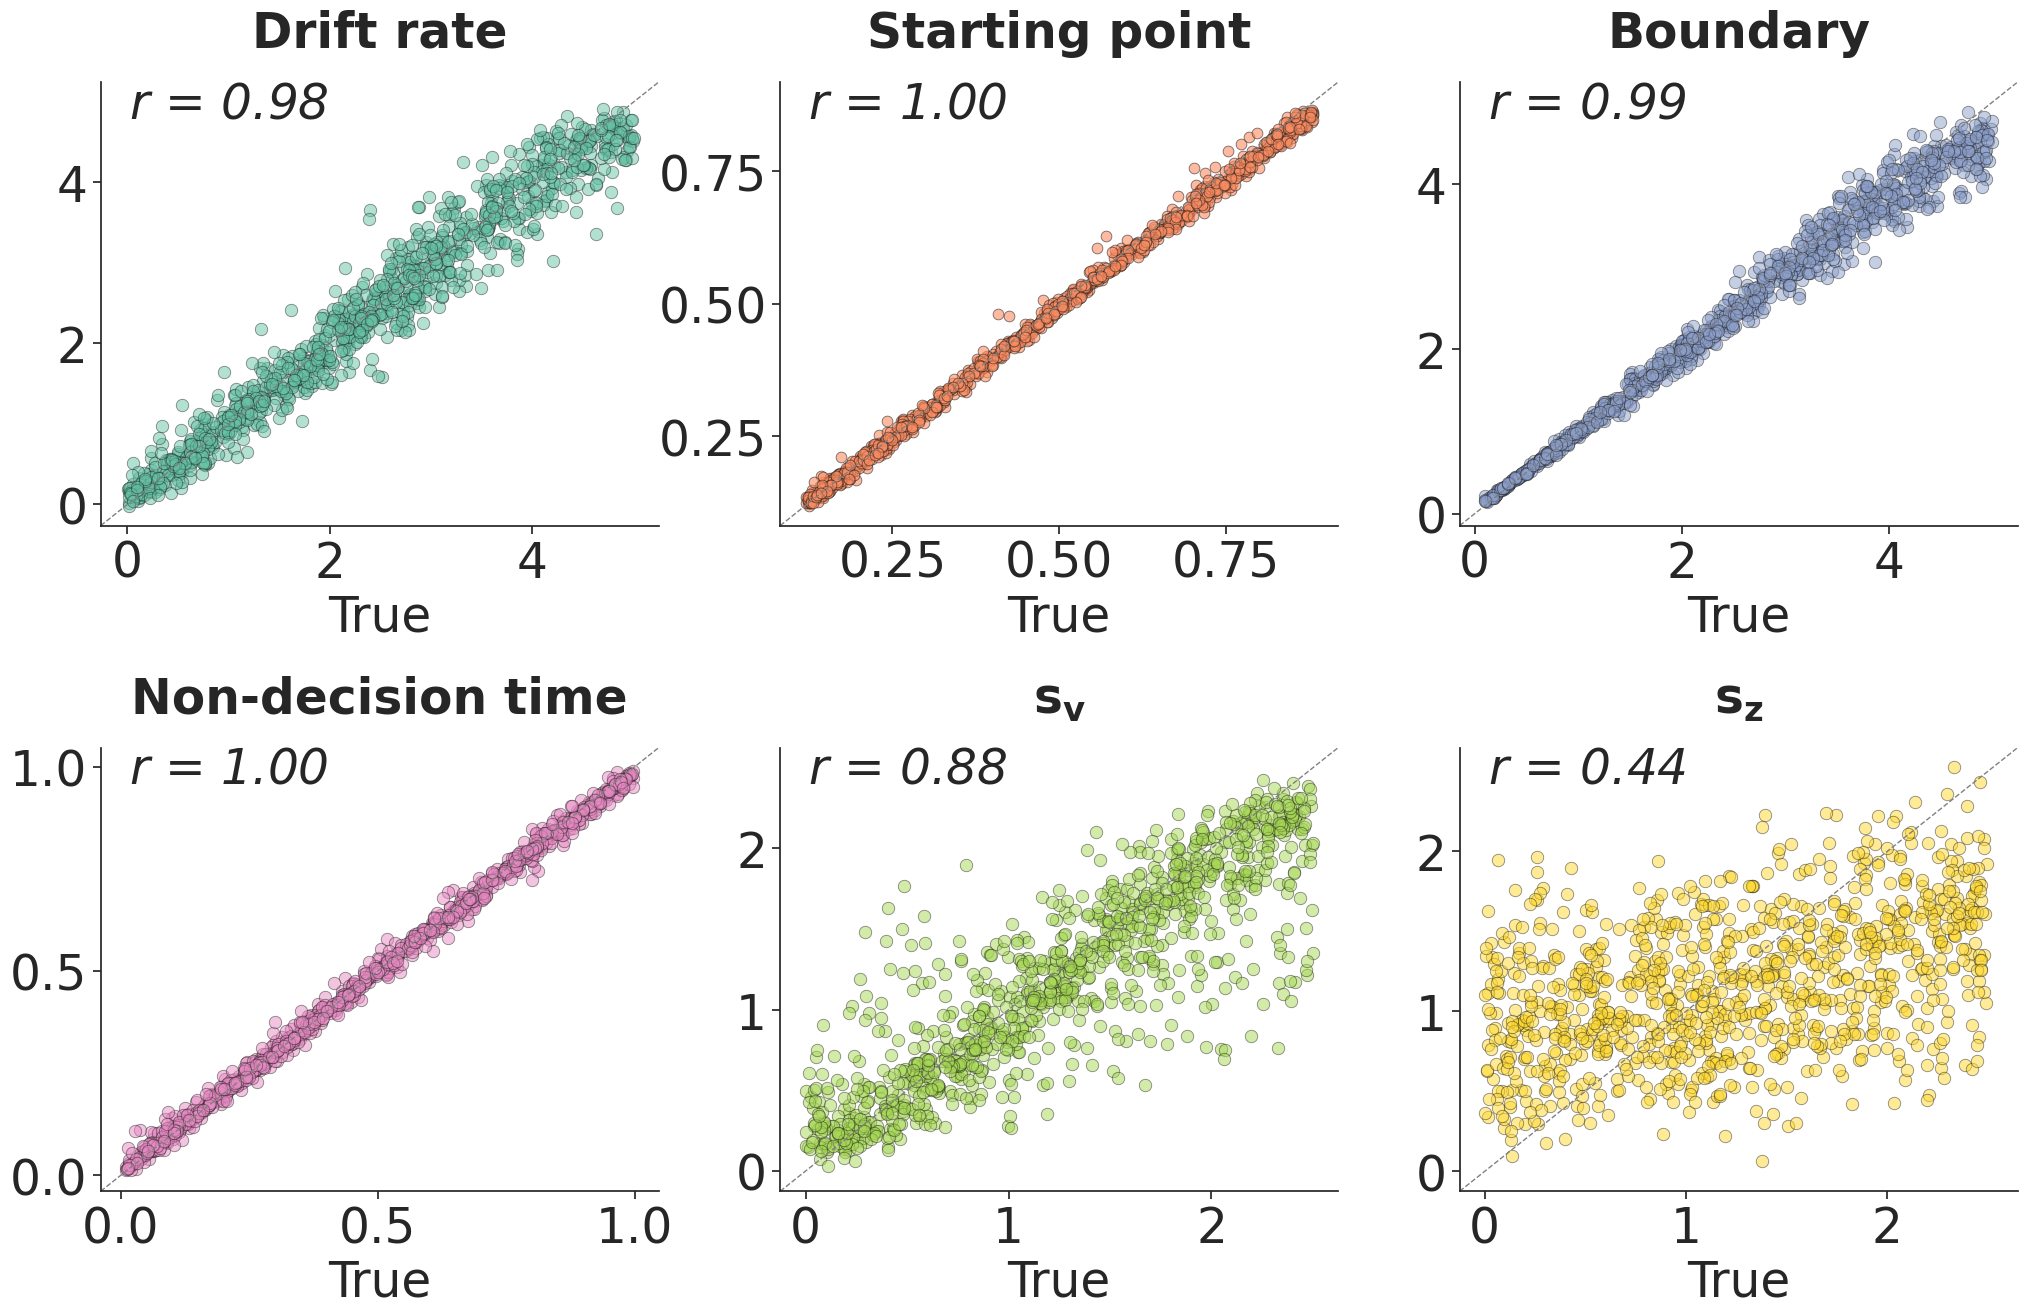

In [18]:
fontsize = 35

shared_param_labels = [
    "Drift rate",
    "Starting point",
    "Boundary",
    "Non-decision time",
    r"$\mathbf{s_v}$",
    r"$\mathbf{s_z}$"
]

# Set seaborn style
sns.set(style="ticks", font_scale=1.7)

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(21, 14))

for i, ax in enumerate(axes.flatten()):
    if i < len(shared_param_labels):
        
        if i == 1:
            ax.scatter(1/(1+np.exp(-true_shared[:, i])), 1/(1+np.exp(-estimated_shared_mean[:, i])),
                       alpha=0.6, s=60, edgecolor='k', linewidth=0.6, color=sns.color_palette("Set2")[i])
        
        else:
            ax.scatter(true_shared[:, i], estimated_shared_mean[:, i],
                   alpha=0.5, s=80, edgecolor='k', linewidth=0.6, color=sns.color_palette("Set2")[i])
        # Labels and title
        ax.set_xlabel("True", fontsize=fontsize)
        #ax.set_ylabel("Inferred", fontsize=fontsize)
        ax.set_title(shared_param_labels[i], fontsize=fontsize, weight='bold',pad=25)
        
        if i == 1:
            x = 1/(1+np.exp(-true_shared[:, i]))
            y = 1/(1+np.exp(-estimated_shared_mean[:, i]))
        else:
            x = true_shared[:, i]
            y = estimated_shared_mean[:, i]

        # Spearman correlation
        r, _ = pearsonr(true_shared[:, i], estimated_shared_mean[:, i])
        ax.annotate(f'$r$ = {r:.2f}', xy=(0.05, 0.92),
                    xycoords='axes fraction', fontsize=fontsize, style='italic')

        # Identity line
        min_val = min(ax.get_xlim()[0], ax.get_ylim()[0])
        max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
        ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='gray', linewidth=1)
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)

        ax.tick_params(labelsize=fontsize)

        # Clean up
        sns.despine(ax=ax)
    else:
        ax.axis('off')

# Title and layout
#fig.suptitle("Shared Parameters Recovery", fontsize=26, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.5)
plt.savefig('Figures/recovery_variability_ddm_shared_params.png', dpi=300)
plt.show()

## 2. Simulation-based calibration (SBC)

Generate data with true posterior mean, then fit data, and calculate the rank statistic of that true posterior mean in the estimated posterior. 

If unbiased then there should be a uniform distribution.

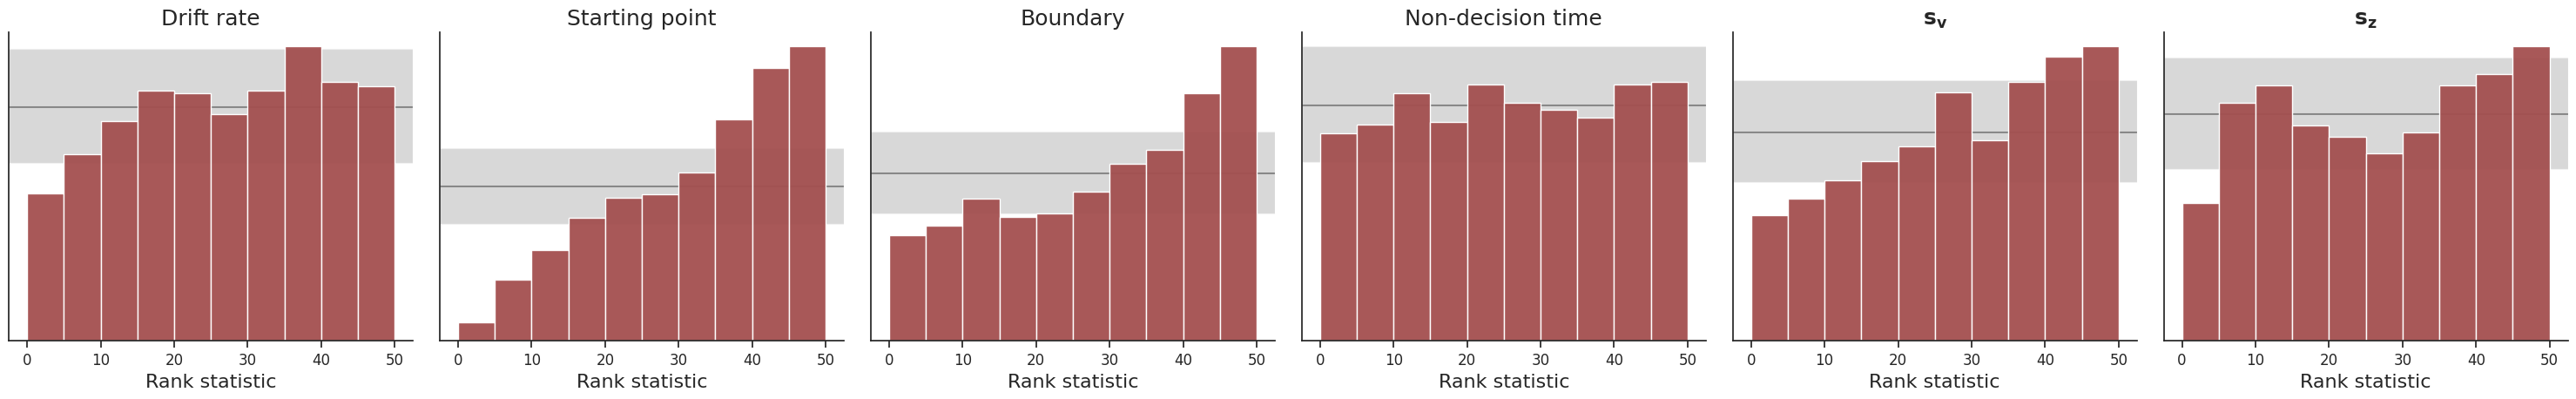

In [19]:
f = bf.diagnostics.plot_sbc_histograms(estimated_shared, true_shared, num_bins=10, param_names=shared_param_labels)

In [20]:
# Posterior std for one example dataset
estimated_shared_std[0]

array([0.35909417, 0.05805318, 0.20088852, 0.02417471, 0.2040945 ,
       0.52098079])

## 3. Posterior z-score vs posterior contraction

Posterior z-score: if your posterior is well-calibrated and centered, the values should be distributed like a standard normal (unbiased when mean = 0, correct uncertainty calibration when variance = 1)

Posterior contraction: 
measures how much the posterior shrinks relative to the prior — i.e., how informative the data are for that parameter. If 0 then posterior variance = prior variance so data were not informative. If close to 1 then good learning


In [21]:
true_shared

array([[ 2.99216915,  0.08193111,  3.12876808,  0.06001771,  0.59578246,
         1.56067422],
       [ 0.83508842, -0.07902861,  4.78984559,  0.13007042,  2.22903758,
         1.40589357],
       [ 2.7037747 ,  0.93728081,  0.29335762,  0.08514846,  1.1664648 ,
         1.14931488],
       ...,
       [ 2.40901446,  0.58868074,  2.52047119,  0.29515947,  1.20511162,
         1.4075296 ],
       [ 1.88990542, -1.22090423,  3.97356855,  0.72240085,  1.83730723,
         0.75787583],
       [ 2.10944653, -0.27439253,  4.25924082,  0.16518276,  2.12983037,
         0.949036  ]])

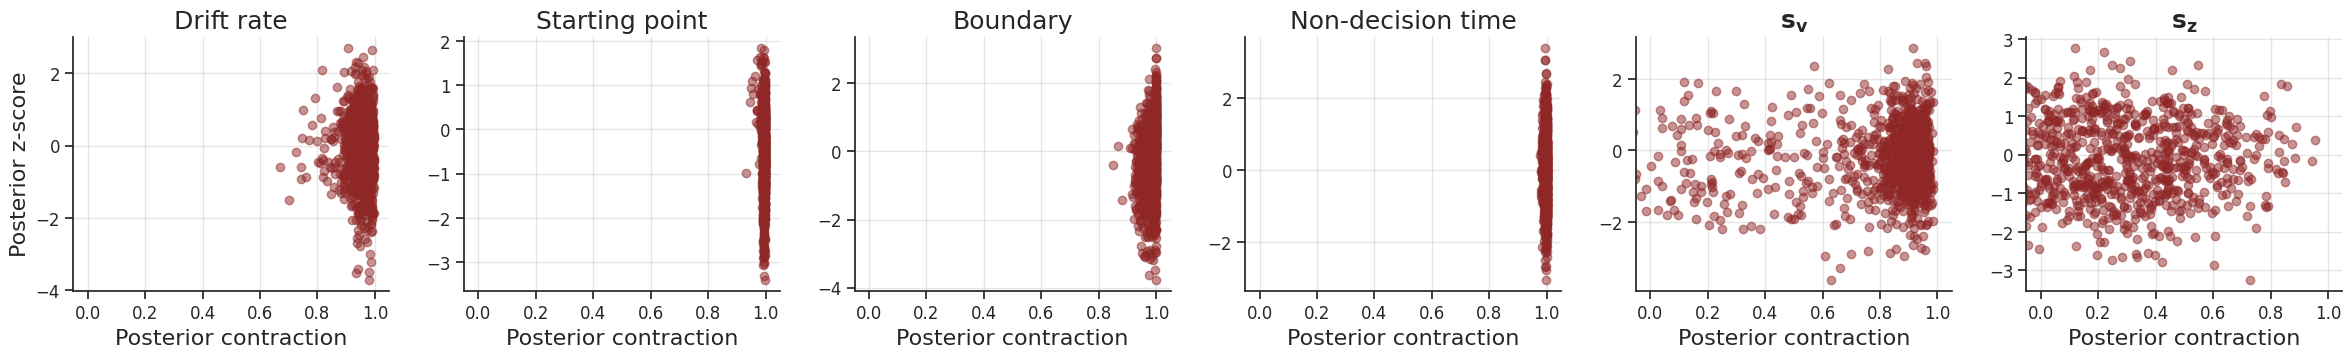

In [22]:
f = bf.diagnostics.plot_z_score_contraction(
    estimated_shared, 
    true_shared,
    param_names=shared_param_labels
)

## 4. RT distributions

1) Simulate data with our generative model.
2) Fit the model to these data.
3) Resimulate new data with samples from the obtained posterior.
4) Compare (summary of) the simulated data and the resimulated data (model prediction).

In [23]:
# Define re-simulation settings
num_simulated_datasets = 6
num_posterior_samples = 100
num_resimulated_datasets = 6

In [24]:
# Step 1
simulated_data = generative_model(batch_size=num_simulated_datasets)
configurated_data = trainer.configurator(simulated_data)

num_obs = simulated_data["sim_data"].shape[1]

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 94 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


In [25]:
simulated_data

{'prior_non_batchable_context': None,
 'prior_batchable_context': None,
 'prior_draws': array([[ 0.79114812,  1.72667612,  2.01587152,  0.35533656,  1.04984954,
          1.59011365],
        [ 0.29753305,  0.88517018,  1.39947563,  0.27743555,  0.61982437,
          0.93064649],
        [ 0.65488626,  1.40773831,  0.44830257,  0.22838537,  1.08026465,
          0.19121966],
        [ 1.32392577,  1.65606085,  3.45197487,  0.40203433,  0.19596693,
          2.22014299],
        [ 4.03454714, -1.86435582,  0.4118102 ,  0.41305273,  0.65896053,
          1.02707367],
        [ 4.00990146,  0.93201418,  2.82993838,  0.69260695,  0.72281907,
          1.63890937]]),
 'sim_non_batchable_context': 500,
 'sim_batchable_context': [array([ 9.98385717e-01, -6.69863842e-02, -3.68356591e-01,  8.31123593e-01,
         -9.37235141e-01, -5.25745250e-01, -3.90017807e-01, -9.50094974e-01,
         -4.24071364e-01,  1.99508157e-01,  3.15708284e-01,  9.23870756e-01,
         -4.73226761e-01, -4.26890214e

In [26]:
configurated_data

{'parameters': array([[-0.8202489 ,  8.180028  , -0.28038162, -1.855961  , -0.38428897,
          0.65301824],
        [-1.0571842 ,  5.6555104 , -0.5762517 , -2.7907734 , -1.2099373 ,
         -0.61315876],
        [-0.8856546 ,  7.2232146 , -1.0328147 , -3.3793752 , -0.32589182,
         -2.0328584 ],
        [-0.56451565,  7.968182  ,  0.408948  , -1.2955881 , -2.0237436 ,
          1.8626748 ],
        [ 0.73658276, -2.5930674 , -1.0503311 , -1.163367  , -1.1347958 ,
         -0.42801866],
        [ 0.7247528 ,  5.7960424 ,  0.11037049,  2.1912832 , -1.0121874 ,
          0.74670595]], dtype=float32),
 'summary_conditions': array([[[-0.9154497 ,  1.        ,  0.9983857 ],
         [ 1.2000662 ,  0.        , -0.06698638],
         [-0.77579737,  1.        , -0.3683566 ],
         ...,
         [ 0.04433895,  0.        , -0.7889868 ],
         [-0.6629351 ,  1.        ,  0.6348468 ],
         [-0.5792176 ,  1.        ,  0.2799358 ]],
 
        [[-0.5067746 ,  0.        , -0.99113667]

In [27]:
# Step 2

# Fit model -> draw 1000 posterior samples per data set
posterior_samples = amortizer.sample(configurated_data, n_samples=num_posterior_samples)
# Unstandardize posteriors draws into original scale
posterior_samples_unstandardized = posterior_samples * std_shared + mean_shared

In [28]:
estimated_posterior_means = posterior_samples_unstandardized.mean(axis=1)
estimated_posterior_means

array([[ 0.36073621,  1.49812505,  1.90291552,  0.35044171,  0.77956737,
         1.26546048],
       [ 0.39619145,  0.87555065,  1.42145687,  0.28247827,  0.453962  ,
         1.26077628],
       [ 0.45839865,  1.21009979,  0.48568981,  0.22794049,  1.40703344,
         1.68269771],
       [ 1.5463774 ,  1.69351889,  3.73934989,  0.38577758,  0.28182854,
         1.53378676],
       [ 3.80278679, -1.85420858,  0.42893221,  0.41273583,  1.01781684,
         1.26492082],
       [ 4.37023466,  0.88752958,  2.91428544,  0.69068915,  0.94039416,
         1.76018091]])

In [29]:
true_posterior_means = simulated_data['prior_draws']
true_posterior_means

array([[ 0.79114812,  1.72667612,  2.01587152,  0.35533656,  1.04984954,
         1.59011365],
       [ 0.29753305,  0.88517018,  1.39947563,  0.27743555,  0.61982437,
         0.93064649],
       [ 0.65488626,  1.40773831,  0.44830257,  0.22838537,  1.08026465,
         0.19121966],
       [ 1.32392577,  1.65606085,  3.45197487,  0.40203433,  0.19596693,
         2.22014299],
       [ 4.03454714, -1.86435582,  0.4118102 ,  0.41305273,  0.65896053,
         1.02707367],
       [ 4.00990146,  0.93201418,  2.82993838,  0.69260695,  0.72281907,
         1.63890937]])

In [30]:
# Step 3

# Get context of simulated data sets
context = simulated_data["sim_batchable_context"]

predicted_data = sample_multiple_diffusion_trials(estimated_posterior_means, context, num_obs)

In [31]:
predicted_data.shape

(6, 500, 2)

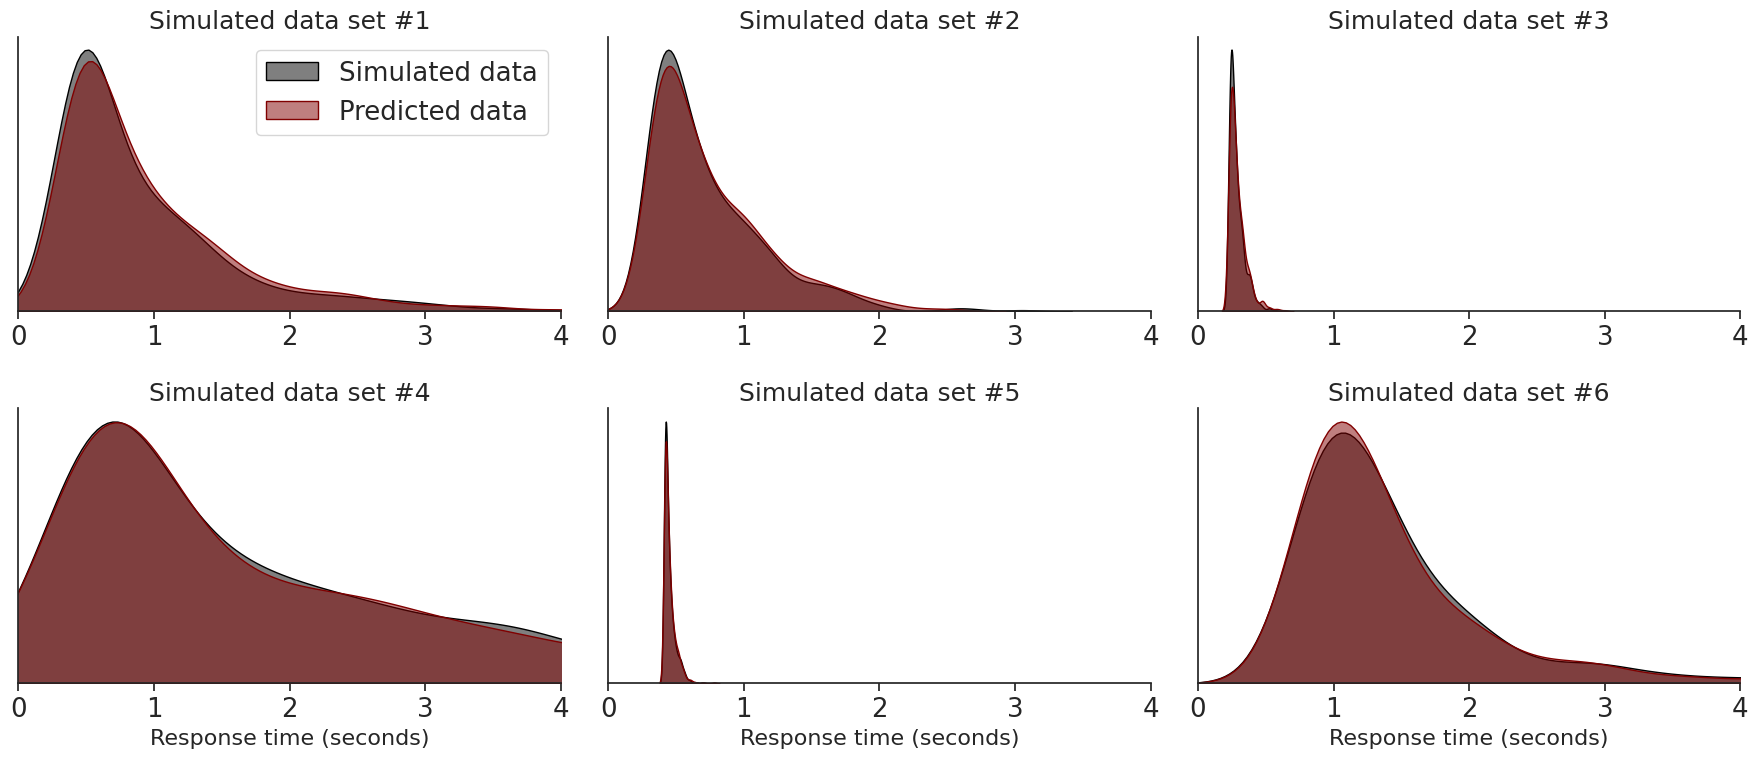

In [32]:
f, axarr = plt.subplots(2, 3, figsize=(18, 8))
for i, ax in enumerate(axarr.flat):
    sns.kdeplot(
        simulated_data["sim_data"][i, :, 0], ax=ax, fill=True, color="black", alpha=0.5, label="Simulated data"
    )
    sns.kdeplot(predicted_data[i, :, 0].flatten(), ax=ax, fill=True, color="maroon", alpha=0.5, label="Predicted data")
    ax.set_xlim((0, 4))
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_title(f"Simulated data set #{i+1}", fontsize=18)
    # Set legend to first plot
    if i == 0:
        ax.legend()

    # Set x label to bottom row
    if i > (num_simulated_datasets // 2) - 1:
        ax.set_xlabel("Response time (seconds)", fontsize=16)
    sns.despine()
f.tight_layout()